# Figures 8.3 and 8.4: Proposed method of image selection with autoencoders.

This notebook demonstrates a method of image selection using the latent vectors of an autoencoder model.
Vectors labelled 'four' were averaged and decoded using the saved model weights, then practical images were defined in vector space.

In [1]:
%matplotlib widget
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2DTranspose, ReLU
from tensorflow.keras.datasets import mnist
from pathlib import Path

np.random.seed(42)
tf.random.set_seed(42)

# ─────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────
RESULTS_DIR       = Path("..") / "data" / "mnist-ae"
LATENTS_H5        = RESULTS_DIR / "latents.h5"
DECODER_WEIGHTS   = RESULTS_DIR / "decoder_weights.h5"

# Must match training
N_LAYERS      = 2
BASE_FILTERS  = 16
LATENT_DIM    = 64
TARGET_LABEL  = 4

# Geometric median settings
GEOMED_MAX_ITERS = 1000
GEOMED_TOL       = 1e-7
GEOMED_SUBSAMPLE = None

# ─────────────────────────────────────────────────────────
# Load latents
# ─────────────────────────────────────────────────────────
with h5py.File(LATENTS_H5, "r") as hf:
    Z      = hf["z"][:].astype(np.float32)
    labels = hf["labels"][:].astype(np.int64)

# ─────────────────────────────────────────────────────────
# Load images
# ─────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = np.expand_dims(x_train.astype("float32") / 255.0, -1)
x_test  = np.expand_dims(x_test.astype("float32")  / 255.0, -1)

ALL_IMAGES = np.concatenate([x_train, x_test], axis=0)

# ─────────────────────────────────────────────────────────
# Filter for target label
# ─────────────────────────────────────────────────────────
idx_subset = np.where(labels == TARGET_LABEL)[0]
Z_sub   = Z[idx_subset]

# ─────────────────────────────────────────────────────────
# Build and load decoder
# ─────────────────────────────────────────────────────────
def build_decoder(n_layers=2, base_filters=16, latent_dim=64):
    latent_in = Input((latent_dim,), name="z_sampling")
    spatial   = 28 // (2**n_layers)
    channels  = base_filters * (2**(n_layers-1))
    
    x = Dense(spatial * spatial * channels)(latent_in)
    x = Reshape((spatial, spatial, channels))(x)
    
    for i in reversed(range(n_layers)):
        f = base_filters * (2**i)
        x = Conv2DTranspose(f, 3, strides=(2,2), padding="same")(x)
        x = ReLU()(x)
    
    out = tf.keras.layers.Conv2D(1, 3, padding="same", activation="sigmoid", name="decoder_output")(x)
    return Model(latent_in, out, name="decoder")

decoder = build_decoder(N_LAYERS, BASE_FILTERS, LATENT_DIM)
decoder.load_weights(DECODER_WEIGHTS)

# ─────────────────────────────────────────────────────────
# Compute central latents
# ─────────────────────────────────────────────────────────
def geometric_median(points, tol=1e-7, max_iters=1000):
    P = points.astype(np.float64)
    x = P.mean(axis=0)
    eps = 1e-12
    
    for _ in range(max_iters):
        diff = P - x
        d    = np.linalg.norm(diff, axis=1) + eps
        w    = 1.0 / d
        x_new = (w[:, None] * P).sum(axis=0) / w.sum()
        
        if np.linalg.norm(x_new - x) <= tol:
            return x_new.astype(np.float32)
        x = x_new
    
    return x.astype(np.float32)

mean_z   = Z_sub.mean(axis=0)
median_z = np.median(Z_sub, axis=0)

if GEOMED_SUBSAMPLE is None or GEOMED_SUBSAMPLE >= Z_sub.shape[0]:
    gm_input = Z_sub
else:
    sel = np.random.choice(Z_sub.shape[0], GEOMED_SUBSAMPLE, replace=False)
    gm_input = Z_sub[sel]

geom_median_z = geometric_median(gm_input, tol=GEOMED_TOL, max_iters=GEOMED_MAX_ITERS)

# ─────────────────────────────────────────────────────────
# Reconstruct from central latents
# ─────────────────────────────────────────────────────────
central_stack = np.stack([mean_z, median_z, geom_median_z], axis=0).astype(np.float32)
recons = decoder.predict(central_stack, verbose=0)
recons = np.squeeze(recons, axis=-1)

# ─────────────────────────────────────────────────────────
# Find nearest real images
# ─────────────────────────────────────────────────────────
def nearest_idx(vec, Z):
    diff = Z - vec[None, :]
    d2   = np.sum(diff*diff, axis=1)
    return int(np.argmin(d2))

mean_i_sub   = nearest_idx(mean_z, Z_sub)
median_i_sub = nearest_idx(median_z, Z_sub)
geom_i_sub   = nearest_idx(geom_median_z, Z_sub)

closest_images = [
    ALL_IMAGES[idx_subset[mean_i_sub], ..., 0],
    ALL_IMAGES[idx_subset[median_i_sub], ..., 0],
    ALL_IMAGES[idx_subset[geom_i_sub], ..., 0]
]

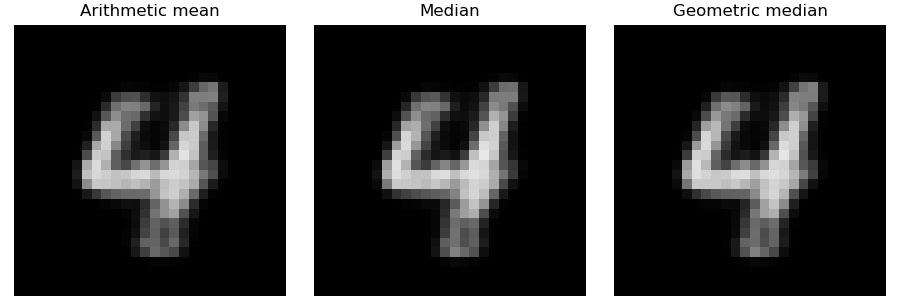

In [2]:
# ─────────────────────────────────────────────────────────
# Plot reconstructions
# ─────────────────────────────────────────────────────────
#| label: fig8c_data
METHOD_TITLES = ["Arithmetic mean", "Median", "Geometric median"]

fig1, axes1 = plt.subplots(1, 3, figsize=(9, 3), constrained_layout=True)
for ax, img, title in zip(axes1, recons, METHOD_TITLES):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
fig1.canvas.header_visible = False
plt.show()

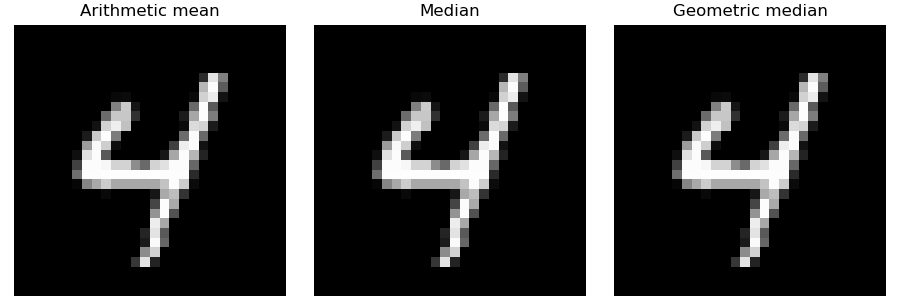

In [3]:
# ─────────────────────────────────────────────────────────
# Plot nearest real images
# ─────────────────────────────────────────────────────────
#| label: fig8d_data
fig2, axes2 = plt.subplots(1, 3, figsize=(9, 3), constrained_layout=True)
for ax, img, title in zip(axes2, closest_images, METHOD_TITLES):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
fig2.canvas.header_visible = False
plt.show()